# `2.9`

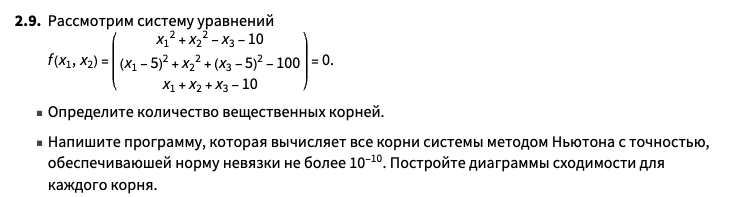

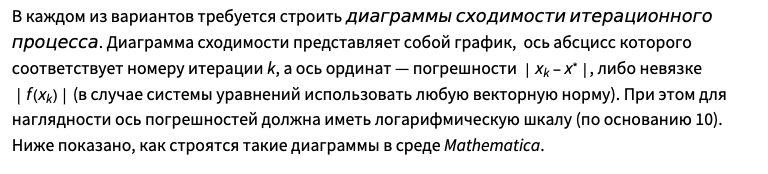

## Определение количества корней

для этого я выразил из третьего уравнения $x_3$ и подставил в первое и второе \
далее с помощью сайта [desmos](https://www.desmos.com/calculator) построил уравнения получившегося первого и второго уравнений

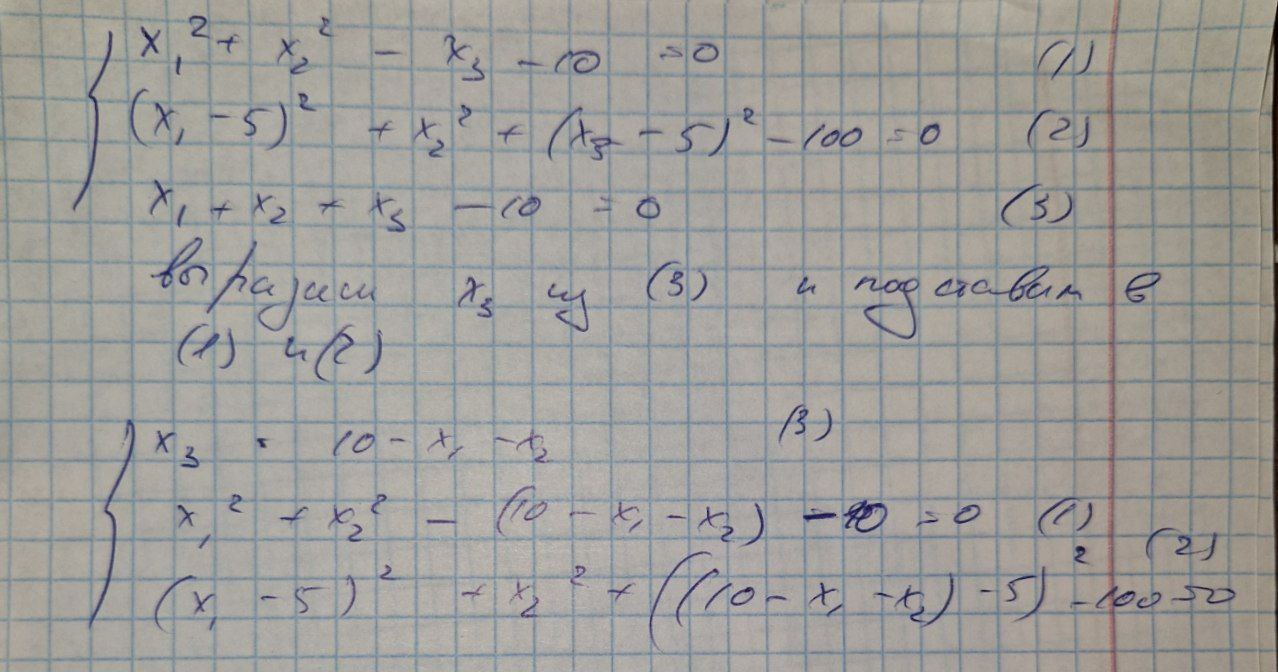

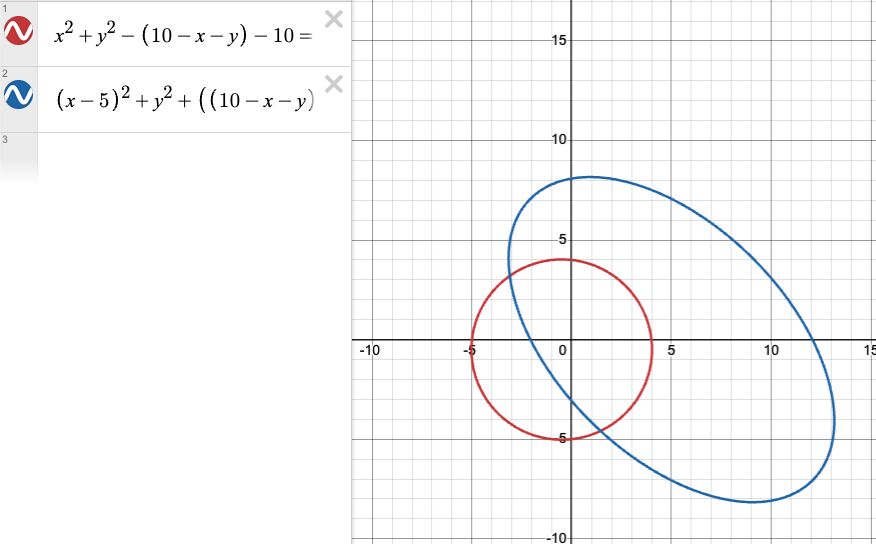

итого вышло 2 корня

## Напишите программу, которая вычисляет все корни системы методом Ньютона с точностью, обеспечиваюшей норму невязки не более $10^{-10}$ . Постройте диаграммы сходимости для каждого корня.

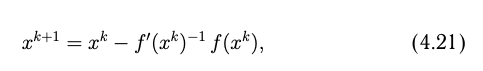

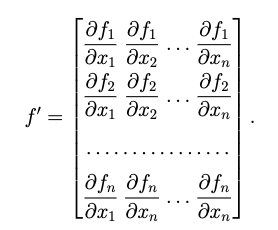

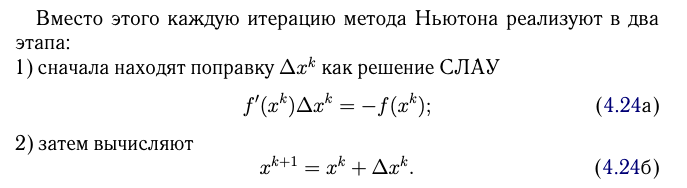

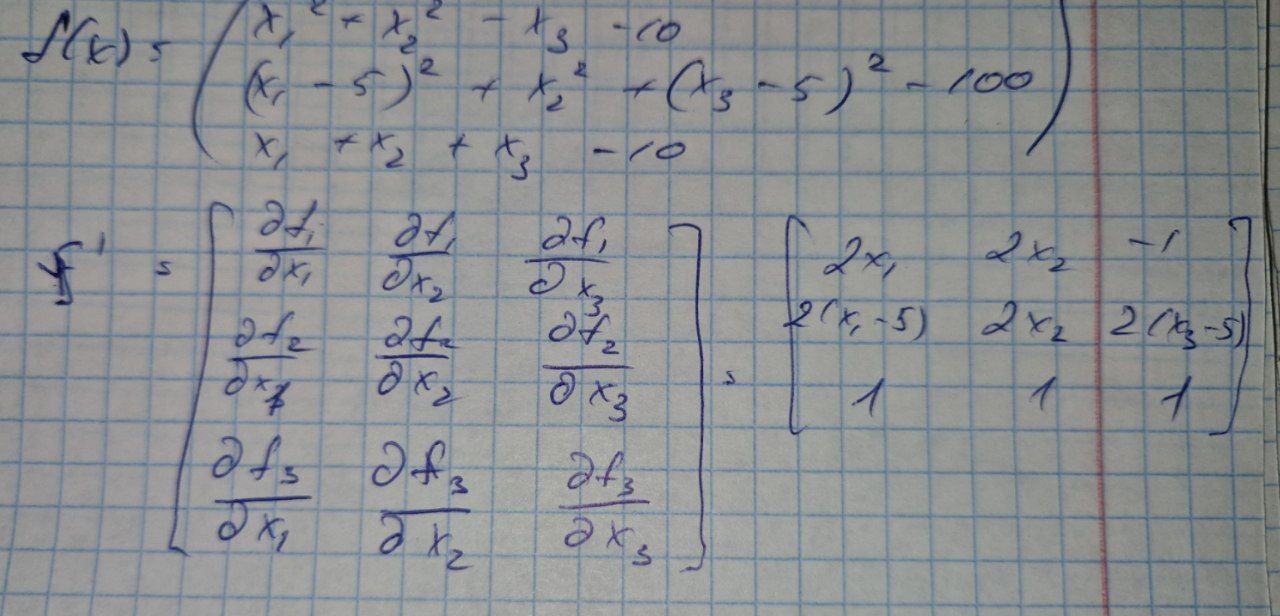

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def system_f(x):
    x1, x2, x3 = x
    f1 = x1**2 + x2**2 - x3 - 10
    f2 = (x1 - 5)**2 + x2**2 + (x3 - 5)**2 - 100
    f3 = x1 + x2 + x3 - 10
    return np.array([f1, f2, f3])

def jacobian(x):
    x1, x2, x3 = x

    df1_dx1 = 2 * x1
    df1_dx2 = 2 * x2
    df1_dx3 = -1
    
    df2_dx1 = 2 * (x1 - 5)
    df2_dx2 = 2 * x2
    df2_dx3 = 2 * (x3 - 5)
    
    df3_dx1 = 1
    df3_dx2 = 1
    df3_dx3 = 1
    
    return np.array([
        [df1_dx1, df1_dx2, df1_dx3],
        [df2_dx1, df2_dx2, df2_dx3],
        [df3_dx1, df3_dx2, df3_dx3]
    ])

In [6]:
def newton_system_method(
    f, # вектор-функция
    jacobian_function, # матрица якоби
    x0, # начальное приближение
    eps=1e-10,
    max_iterations=50
):
    x_k = np.array(x0, dtype=float)
    residuals = [] # для норм невязки ||f(x)||
    f_val = f(x_k)
    residual_norm = np.linalg.norm(f_val) # евклидова норма (по умолчанию)
    residuals.append(residual_norm)
    
    for k in range(max_iterations):
        if residual_norm < eps:
            break
            
        J_val = jacobian_function(x_k) # якоби
        
        # 2. Решаем СЛАУ J * dx = -f (вместо обращения матрицы)
        # Используем np.linalg.solve для точности и скорости
        try:
            # формула 4.24а
            dx = np.linalg.solve(J_val, -f_val) # применяется LU разложение
        except np.linalg.LinAlgError: # эта ошибка падает, если в Ax = b, A -- вырождена
            print("Матрица Якоби вырождена")
            break
            
        # формула 4.24б
        x_k = x_k + dx
        
        # считаем новую невязку
        f_val = f(x_k)
        residual_norm = np.linalg.norm(f_val)
        residuals.append(residual_norm)
        
    return x_k, residuals

корень #1 найден за 8 итераций
координаты: x1=-3.105738, x2=3.202719, x3=9.903019
невязка: 2.89e-14
------------------------------------------------------------
корень #2 найден за 4 итераций
координаты: x1=1.445352, x2=-4.588472, x3=13.143120
невязка: 1.78e-15
------------------------------------------------------------


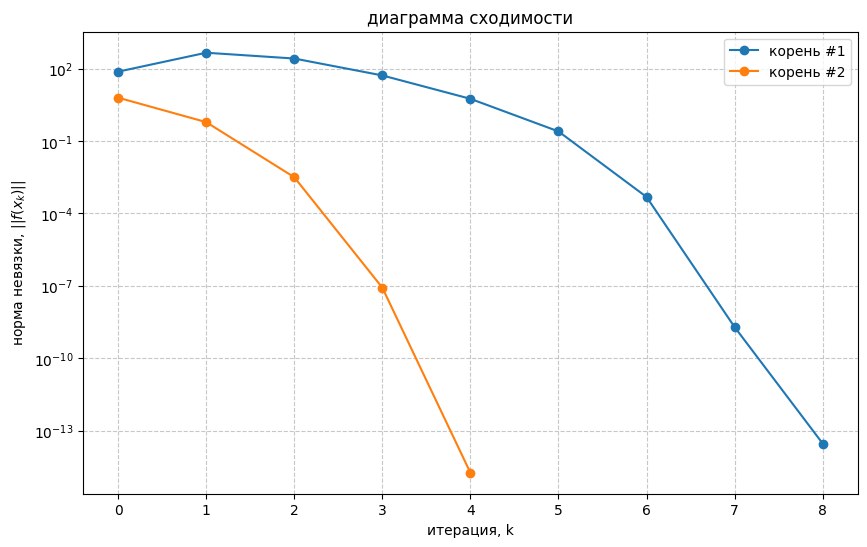

In [11]:
# так как у нас два корня, то нужно просмотреть с нескольких начальный точек
# вот несколько точек
x0s = [
    [1, 1, 8],
    [5, 5, 0],
    [-5, 5, 10],
    [2, -5, 13]
]
found_roots = [] # найденные корни

plt.figure(figsize=(10, 6))

for i, x0 in enumerate(x0s):
    root, history = newton_system_method(system_f, jacobian, x0)
    
    # проверка, что в списке нет такого корня    
    is_new = True
    for r in found_roots:
        if np.linalg.norm(root - r) < 1e-5:
            is_new = False
            break
    
    if is_new and history[-1] < 1e-9:
        found_roots.append(root)
        print(f"корень #{len(found_roots)} найден за {len(history)-1} итераций")
        print(f"координаты: x1={root[0]:.6f}, x2={root[1]:.6f}, x3={root[2]:.6f}")
        print(f"невязка: {history[-1]:.2e}")
        print(60 * '-')
        plt.plot(range(len(history)), history, 'o-', label=f'корень #{len(found_roots)}')

plt.yscale('log')
plt.xlabel('итерация, k')
plt.ylabel('норма невязки, $||f(x_k)||$')
plt.title('диаграмма сходимости')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend()
plt.show()